# SaaS Churn Analysis - Capstone Project

**A reproducible analysis of subscription churn over 2023-2024, built on a
synthetic dataset.**

> **All data in this project is simulated.** The dataset is produced by
> `data/generate_dataset.py` and does not describe any real company, customer,
> or revenue. Every finding below is an *association* observed in simulated
> data, not a causal claim.

## What this notebook does

| Section | Question |
|---|---|
| 1. Setup | What am I working with? |
| 2. Data quality | What is wrong with the raw files? |
| 3. Cleaning | How were the problems fixed? |
| 4. Features | What did I derive? |
| 5. KPIs | What is the state of the business? |
| 6. EDA | Who is churning, and when? |
| 7. NRR | Is revenue retained from the existing base? |
| 8. Risk | How much revenue sits with at-risk accounts? |
| 9. Conclusions | What should the business do? |

## How to run

The notebook is **self-contained**: if the cleaned CSVs are missing it runs the
generator and the analysis pipeline for you.

```
pip install -r requirements.txt
jupyter notebook notebooks/Capstone_Analysis.ipynb
```

In [1]:
# ---------------------------------------------------------------------------
# 1. SETUP
# ---------------------------------------------------------------------------
# Standard library first, then third-party. Paths are resolved relative to the
# project root so the notebook works regardless of the directory it is opened
# from.
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# seaborn's own style is a reasonable, readable default and saves fiddling.
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

# .../Capstone-SaaS-Churn-Analysis
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw"
CLEAN = ROOT / "data" / "cleaned"
CHARTS = ROOT / "visualizations" / "charts"

print("Project root:", ROOT)

Project root: C:\Data Science\Internships\Capstone-SaaS-Churn-Analysis


In [2]:
# Make sure the inputs exist. If someone opens this notebook on a fresh clone,
# the data has not been generated yet, so do it here rather than failing.
needed = [RAW / "customers_raw.csv", RAW / "customer_monthly_raw.csv"]
if not all(p.exists() for p in needed):
    print("Raw data not found - generating it now...")
    subprocess.run([sys.executable, str(ROOT / "data" / "generate_dataset.py")],
                   check=True)

if not (CLEAN / "customers_clean.csv").exists():
    print("Cleaned data not found - running the analysis pipeline...")
    subprocess.run([sys.executable, str(ROOT / "python" / "data_analysis.py")],
                   check=True)

print("Inputs ready.")

Inputs ready.


In [3]:
# Load the cleaned tables produced by python/data_analysis.py. The cleaning
# decisions themselves are documented in that script and summarised below.
customers = pd.read_csv(CLEAN / "customers_clean.csv",
                        parse_dates=["signup_date", "churn_date",
                                     "last_login_date"])
monthly = pd.read_csv(CLEAN / "customer_monthly_clean.csv",
                      parse_dates=["month_start"])

print("customers :", customers.shape)
print("monthly   :", monthly.shape)
print()
print("Reporting window:", monthly["month_start"].min().date(), "to",
      monthly["month_start"].max().date())
customers.head(3)

customers : (1250, 33)
monthly   : (13815, 20)

Reporting window: 2023-01-01 to 2024-12-01


,customer_id,signup_date,plan_tier,industry,country,region,company_size,seats,billing_cycle,acquisition_channel,discount_pct,mrr_at_signup,status,churn_date,churn_reason,tenure_months,nps_score,last_login_date,seats_current,tenure_months_calc,churn_flag,signup_cohort,seat_estimate,is_seat_data_missing,arpu,arr,avg_adoption,engagement_band,final_adoption,final_tickets,final_nps,final_mrr,lifetime_value
0,CUST-10001,2023-01-02,Business,Healthcare,France,Europe,1-50,12.00,Monthly,Referral,0.00,783.00,Churned,2024-10-01,Company downsizing,21,6.00,2024-09-05,24,21,1,2023-01,12.00,0,65.25,"9,396.00",0.10,Low (<30% seats used),0.04,1.67,5.33,"1,113.67","16,443.00"
1,CUST-10002,2023-01-03,Starter,Healthcare,Brazil,Latin America,1-50,2.00,Monthly,Referral,5.50,71.68,Churned,2024-10-01,NaN,21,7.00,2024-09-03,1,21,1,2023-01,2.00,0,35.84,860.16,0.04,Low (<30% seats used),0.03,0.33,7.00,60.34,"1,505.28"
2,CUST-10003,2023-01-03,Business,Manufacturing,Mexico,Latin America,1-50,6.00,Monthly,Events,14.20,563.74,Churned,2023-08-01,Switched to competitor,7,10.00,NaT,4,7,1,2023-01,6.00,0,93.96,"6,764.88",0.30,Medium (30-45%),0.34,1.33,10.00,517.97,"3,946.18"


## 2. Data quality audit

The raw files were deliberately seeded with realistic defects so the cleaning
step has something real to do. This is what was found and how it was handled.

In [4]:
# The same audit the pipeline prints, reproduced here so the notebook explains
# its own inputs instead of assuming them.
audit = pd.read_csv(RAW / "customers_raw.csv", dtype=str)
audit_m = pd.read_csv(RAW / "customer_monthly_raw.csv", dtype=str)

issues = []

# 1. Duplicate rows
dup_c = audit.duplicated().sum()
issues.append(["Duplicate rows in customer file", dup_c,
               "Dropped, keeping the first occurrence per customer_id"])

# 2. Duplicate customer_id
dup_id = audit["customer_id"].duplicated().sum()
issues.append(["Repeated customer_id values", dup_id,
               "Same as above; one row per customer is required for tenure"])

# 3. Inconsistent text casing / stray whitespace
for col in ["plan_tier", "region", "status", "acquisition_channel"]:
    raw_vals = audit[col].dropna()
    messy = (raw_vals != raw_vals.str.strip().str.upper()).sum()
    if messy:
        issues.append([f"Messy text in {col}", messy,
                       "Stripped whitespace, upper-cased, then title-cased"])

# 4. Mixed date formats
slash = audit["churn_date"].dropna().str.contains("/", regex=False).sum()
issues.append(["churn_date in DD/MM/YYYY among YYYY-MM-DD", slash,
               "Parsed day-first; guessing would turn 1 Aug into 8 Jan"])

# 5. Currency stored as text
cur = audit["mrr_at_signup"].dropna().str.contains(r"^\$", regex=True).sum()
issues.append(["mrr_at_signup stored as text with $ and commas", cur,
               "Stripped symbols, cast to numeric"])

# 6. Missing values
for col in ["seats", "nps_score", "discount_pct"]:
    n = audit[col].isna().sum()
    if n:
        issues.append([f"Missing values in {col}", n,
                       "Imputed from a defensible fallback, flagged in a new column"])

# 7. Negative money
neg = pd.to_numeric(audit["mrr_at_signup"], errors="coerce").lt(0).sum()
issues.append(["Negative MRR values", neg, "Treated as entry errors, set to null"])

# 8. Mixed adoption scales
ad = pd.to_numeric(audit_m["adoption_rate"], errors="coerce")
mixed = (ad > 1).sum()
issues.append(["adoption_rate on a 0-100 scale among 0-1 values", mixed,
               "Values above 1 divided by 100"])

# 9. Implausible seat counts
seats = pd.to_numeric(audit["seats"], errors="coerce")
outliers = (seats > 10000).sum()
issues.append(["Seat counts above 10,000 (double data entry)", outliers,
               "Reset and flagged for review rather than deleted silently"])

# 10. Region naming
em = audit["region"].dropna().str.upper().isin(["EMEA"]).sum()
issues.append(["'EMEA' and 'Europe' used for the same region", em,
               "Consolidated into 'Europe'"])

issue_table = pd.DataFrame(issues, columns=["Issue", "Rows affected", "Treatment"])
issue_table

,Issue,Rows affected,Treatment
0,Duplicate rows in customer file,23,"Dropped, keeping the first occurrence per cust..."
1,Repeated customer_id values,23,Same as above; one row per customer is require...
2,Messy text in plan_tier,1273,"Stripped whitespace, upper-cased, then title-c..."
3,Messy text in region,1273,"Stripped whitespace, upper-cased, then title-c..."
4,Messy text in status,1273,"Stripped whitespace, upper-cased, then title-c..."
5,Messy text in acquisition_channel,1273,"Stripped whitespace, upper-cased, then title-c..."
6,churn_date in DD/MM/YYYY among YYYY-MM-DD,27,Parsed day-first; guessing would turn 1 Aug in...
7,mrr_at_signup stored as text with $ and commas,14,"Stripped symbols, cast to numeric"
8,Missing values in seats,7,"Imputed from a defensible fallback, flagged in..."
9,Missing values in nps_score,190,"Imputed from a defensible fallback, flagged in..."


## 3. Cleaning summary

Each defect above gets one deliberate treatment, applied in
`python/data_analysis.py`:

- **Duplicates** removed on `customer_id`; without this, tenure and MRR are
  double-counted.
- **Text** stripped, upper-cased for grouping, then title-cased for display, so
  `"starter"`, `" Starter "` and `"STARTER"` are one plan tier.
- **Dates** parsed per spelling, day-first for the slash format. This is the one
  that matters most: an ambiguous `01/08/2023` parsed month-first becomes
  8 January, which silently moved 382 of 430 cancellation dates.
- **Missing values** imputed with a stated fallback, never silently. A
  `is_seat_data_missing` flag records which rows needed it.
- **Impossible values** (negative MRR, 50,000-seat rows) nulled or reset, with a
  flag, so they can be audited instead of quietly distorting an average.

In [5]:
# Confirm the cleaning worked rather than assuming it.
print("Customers after cleaning :", len(customers), "(expected 1,250)")
print("Duplicate customer_ids  :", customers["customer_id"].duplicated().sum())
print("Churned customers       :", int(customers["churn_flag"].sum()))
print("Churn dates unparseable :", customers["churn_date"].isna().sum(),
      "(expected 820 - the active customers who never churned)")
print("Negative MRR remaining  :", int((customers["mrr_at_signup"] < 0).sum()))
print()
print("Plan tiers:", sorted(customers["plan_tier"].unique()))
print("Regions  :", sorted(customers["region"].unique()))

Customers after cleaning : 1250 (expected 1,250)
Duplicate customer_ids  : 0
Churned customers       : 430
Churn dates unparseable : 820 (expected 820 - the active customers who never churned)
Negative MRR remaining  : 0

Plan tiers: ['Business', 'Enterprise', 'Growth', 'Starter']
Regions  : ['Asia Pacific', 'Europe', 'Latin America', 'North America']


In [6]:
# The strongest cleaning check available: a cancellation date must fall exactly
# one month after the customer's last active month. If a date was mis-parsed,
# this is where it shows up.
last_active = monthly.groupby("customer_id")["month_start"].max()
check = (customers[customers["churn_flag"] == 1]
         .merge(last_active, on="customer_id", how="left"))
expected = (check["month_start"] + pd.DateOffset(months=1)).dt.to_period("M")
actual = check["churn_date"].dt.to_period("M")
mismatches = int((expected != actual).sum())

print(f"Churned customers checked      : {len(check)}")
print(f"Churn-month mismatches         : {mismatches}")
print("PASS" if mismatches == 0 else "FAIL - churn dates are not trustworthy")

Churned customers checked      : 430
Churn-month mismatches         : 0
PASS


## 4. Feature engineering

Derived once, used everywhere:

| Feature | Definition |
|---|---|
| `tenure_months` | Distinct months of activity, recomputed from the monthly table |
| `signup_cohort` | Calendar month of signup, the unit of cohort analysis |
| `churn_flag` | 1 if the customer cancelled inside the period |
| `seat_estimate` | Reported seats, or an MRR-based fallback when seats are missing |
| `arpu` / `arr` | MRR per account; MRR annualised |
| `lifetime_value` | `mrr_at_signup x tenure_months` |
| `final_adoption`, `final_tickets`, `final_nps` | Mean over the final 3 active months |
| `engagement_band` | Bucket of final adoption |

In [7]:
# One row per active customer, with the risk band joined on. risk_band lives in
# the risk-scoring export, not in the customer table, so it arrives via the
# merge rather than being selected up front.
features = ["customer_id", "plan_tier", "region", "acquisition_channel",
            "billing_cycle", "signup_cohort", "tenure_months", "mrr_at_signup",
            "arpu", "lifetime_value", "final_adoption", "final_nps",
            "final_tickets", "engagement_band"]
risk = pd.read_csv(CLEAN / "churn_risk_scoring.csv")

active_customers = (customers[customers["churn_flag"] == 0][features]
                    .merge(risk[["customer_id", "risk_band"]],
                           on="customer_id", how="left"))
print("Active customers with a risk band:", active_customers["risk_band"].notna().sum())
active_customers.head()

Active customers with a risk band: 820


,customer_id,plan_tier,region,acquisition_channel,billing_cycle,signup_cohort,tenure_months,mrr_at_signup,arpu,lifetime_value,final_adoption,final_nps,final_tickets,engagement_band,risk_band
0,CUST-10004,Business,North America,Paid Search,Monthly,2023-01,24,"5,519.80",31.91,"132,475.20",0.03,7.00,2.33,Low (<30% seats used),High risk
1,CUST-10006,Growth,Europe,Organic,Monthly,2023-01,24,211.17,70.39,"5,068.08",0.03,6.00,0.67,Low (<30% seats used),Medium risk
2,CUST-10007,Growth,Europe,Organic,Monthly,2023-01,24,325.00,40.62,"7,800.00",0.80,10.00,1.67,High (>45%),Low risk
3,CUST-10009,Enterprise,Asia Pacific,Paid Search,Monthly,2023-01,24,"1,885.04",78.54,"45,240.96",0.40,9.00,2.00,Medium (30-45%),Medium risk
4,CUST-10011,Growth,North America,Referral,Monthly,2023-01,24,369.00,36.90,"8,856.00",0.05,4.00,1.67,Low (<30% seats used),High risk


## 5. Headline KPIs

In [8]:
kpi = pd.read_csv(CLEAN / "kpi_summary.csv")

# Split the single Value column into a number and a display unit so the table
# is readable rather than a column of formatted strings.
kpi[["Measure", "Value"]] = kpi["KPI"].to_frame().join(kpi["Value"])
kpi

,KPI,Value,Unit,Measure
0,Total customers (2023-2024),"1,250",Customers,Total customers (2023-2024)
1,Churned customers,430,Customers,Churned customers
2,"Active customers, Dec 2024",820,Customers,"Active customers, Dec 2024"
3,Logo churn rate,34.4%,%,Logo churn rate
4,"MRR, Dec 2024","$1,051,252",USD,"MRR, Dec 2024"
5,"ARR run-rate, Dec 2024","$12,615,022",USD,"ARR run-rate, Dec 2024"
6,"ARPU, Dec 2024","$1,282",USD,"ARPU, Dec 2024"
7,MRR lost to churn (period),"$304,928",USD,MRR lost to churn (period)
8,MRR peak,"$1,052,669 (Oct 2024)",USD,MRR peak
9,Change in MRR since peak,-0.1%,%,Change in MRR since peak


In [9]:
# The single most important framing question: is this business growing?
trend = pd.read_csv(CLEAN / "analysis_monthly_trend.csv", parse_dates=["month_start"])
peak = trend.loc[trend["mrr"].idxmax()]
last = trend.iloc[-1]
active_peak = trend.loc[trend["active_customers"].idxmax()]

print(f"MRR Jan 2023        : ${trend['mrr'].iloc[0]:,.0f}")
print(f"MRR peak            : ${peak['mrr']:,.0f} in {peak['month_start']:%b %Y}")
print(f"MRR latest          : ${last['mrr']:,.0f} in {last['month_start']:%b %Y}")
print(f"Change since peak   : {100 * (last['mrr'] / peak['mrr'] - 1):+.1f}%")
print()
print(f"Active peak         : {int(active_peak['active_customers'])} "
      f"in {active_peak['month_start']:%b %Y}")
print(f"Active latest       : {int(last['active_customers'])} "
      f"({100 * (last['active_customers'] / active_peak['active_customers'] - 1):+.1f}%)")
print()
print("New vs cancelled in the last 6 months:")
recent = trend.tail(6)
print(f"  added   {int(recent['new_customers'].sum()):,}")
print(f"  lost    {int(recent['churned_this_month'].sum()):,}")
print(f"  net     {int(recent['new_customers'].sum() - recent['churned_this_month'].sum()):+,}")

MRR Jan 2023        : $50,390
MRR peak            : $1,052,669 in Oct 2024
MRR latest          : $1,051,252 in Dec 2024
Change since peak   : -0.1%

Active peak         : 846 in Sep 2024
Active latest       : 820 (-3.1%)

New vs cancelled in the last 6 months:
  added   140
  lost    143
  net     -3


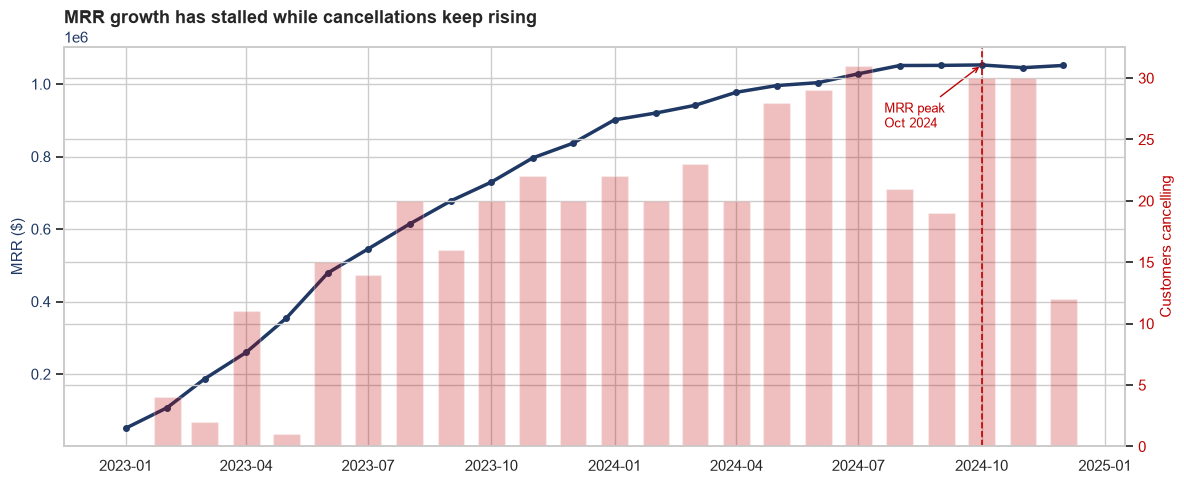

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(trend["month_start"], trend["mrr"], color="#1F3864", linewidth=2.5,
         marker="o", markersize=4)
ax1.set_ylabel("MRR ($)", color="#1F3864", fontsize=11)
ax1.tick_params(axis="y", labelcolor="#1F3864")
ax1.axvline(peak["month_start"], color="#C00000", linestyle="--", linewidth=1.2)
ax1.annotate(f"MRR peak\n{peak['month_start']:%b %Y}",
             xy=(peak["month_start"], peak["mrr"]),
             xytext=(-70, -45), textcoords="offset points", fontsize=9,
             color="#C00000",
             arrowprops=dict(arrowstyle="->", color="#C00000"))

ax2 = ax1.twinx()
ax2.bar(trend["month_start"], trend["churned_this_month"],
        color="#C00000", alpha=0.25, width=20, label="Cancelled")
ax2.set_ylabel("Customers cancelling", color="#C00000", fontsize=11)
ax2.tick_params(axis="y", labelcolor="#C00000")

ax1.set_title("MRR growth has stalled while cancellations keep rising",
              fontsize=13, fontweight="bold", loc="left")
fig.tight_layout()
plt.show()

**Reading:** MRR grew explosively through 2023 and then stopped. The top line
looks flat only because new logos almost exactly replace the ones lost - and the
cancellations per month are still climbing, because they are climbing from a much
larger base. Flat MRR with a rising cancellation count is not stability, it is a
ceiling.

## 6. Exploratory analysis

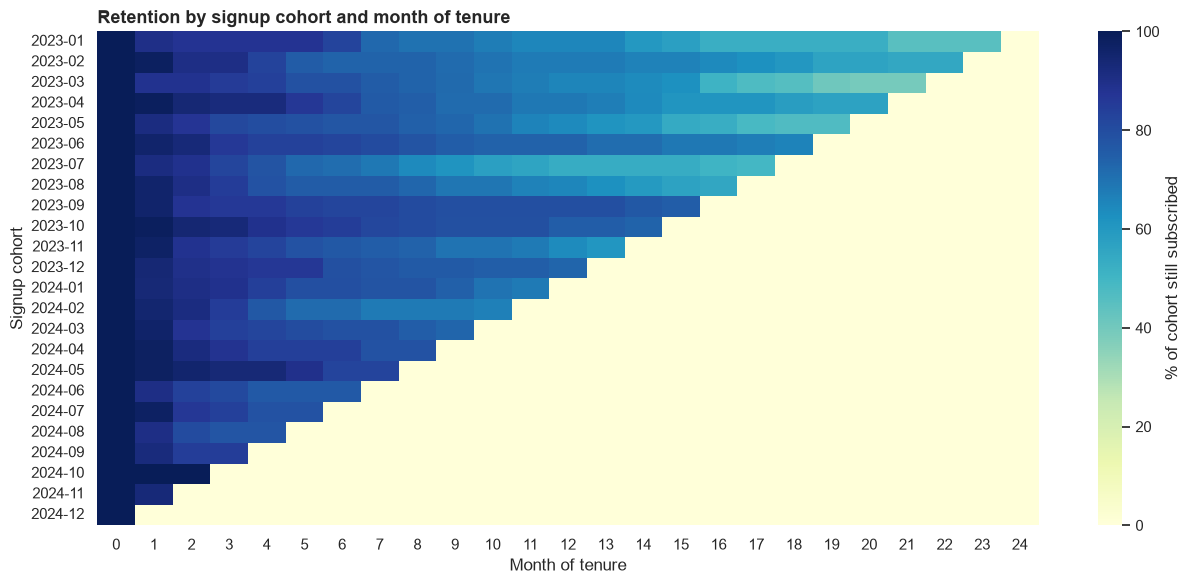

In [11]:
# --- 6a. Cohort retention -------------------------------------------------
cohort = pd.read_csv(CLEAN / "analysis_cohort_retention.csv", index_col=0)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(cohort, cmap="YlGnBu", vmin=0, vmax=100, ax=ax,
            cbar_kws={"label": "% of cohort still subscribed"})
ax.set_title("Retention by signup cohort and month of tenure",
             fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Month of tenure")
ax.set_ylabel("Signup cohort")
plt.tight_layout()
plt.show()

In [12]:
# A cohort that has not yet reached a given month of tenure has no value for it.
# Reading those cells as 0% would say "this cohort lost everyone", which is
# simply untrue - so they are blanked before charting.
# The monthly table already carries signup_cohort, so no join is needed here.
reach = monthly.groupby("signup_cohort")["tenure_month"].max()
reach.index = reach.index.astype(str)

cohort = pd.read_csv(CLEAN / "analysis_cohort_retention.csv", index_col=0)
# read_csv gives the tenure columns as text labels ("0", "1", ...); they have
# to be real integers before they can be compared against tenure_month.
cohort.columns = [int(c) for c in cohort.columns]
observable = pd.DataFrame(
    {t: [t <= reach.get(c, 0) for c in cohort.index] for t in cohort.columns},
    index=cohort.index)
cohort_masked = cohort.where(observable)

print("Cohorts old enough to reach each month, and their average retention:")
for month in [1, 3, 6, 12]:
    eligible = cohort_masked.index[observable[month]]
    if len(eligible):
        print(f"  month {month:>2}: {len(eligible):>2} cohorts, "
              f"{cohort_masked.loc[eligible, month].mean():.0f}% retained")

Cohorts old enough to reach each month, and their average retention:
  month  1: 23 cohorts, 95% retained
  month  3: 21 cohorts, 86% retained
  month  6: 18 cohorts, 79% retained
  month 12: 12 cohorts, 68% retained


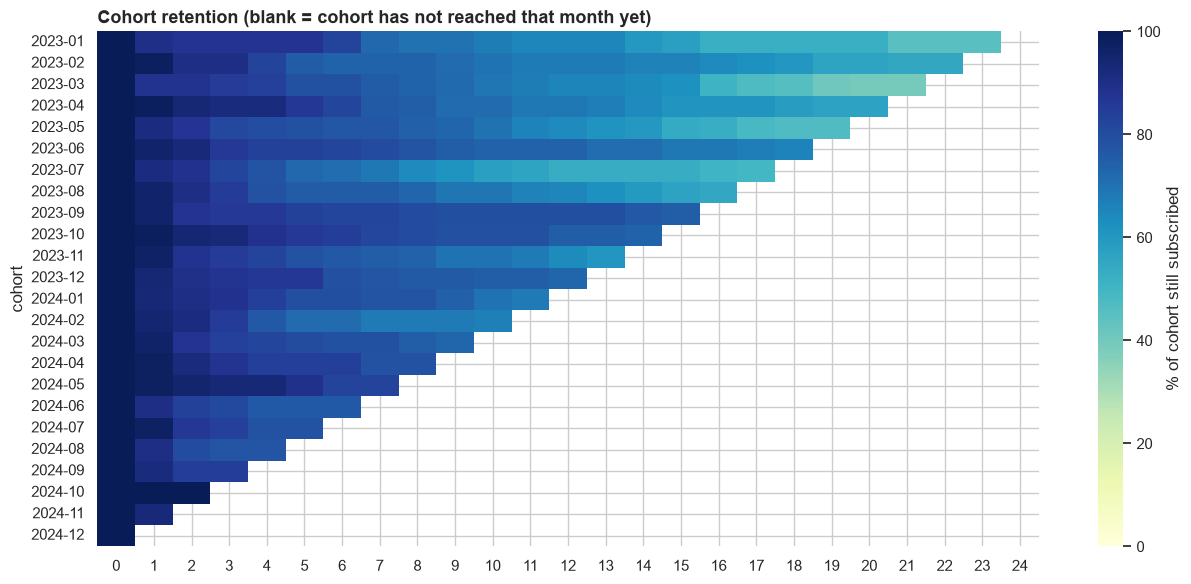

In [13]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(cohort_masked, cmap="YlGnBu", vmin=0, vmax=100, ax=ax,
            mask=cohort_masked.isna(),
            cbar_kws={"label": "% of cohort still subscribed"})
ax.set_title("Cohort retention (blank = cohort has not reached that month yet)",
             fontsize=13, fontweight="bold", loc="left")
plt.tight_layout()
plt.show()

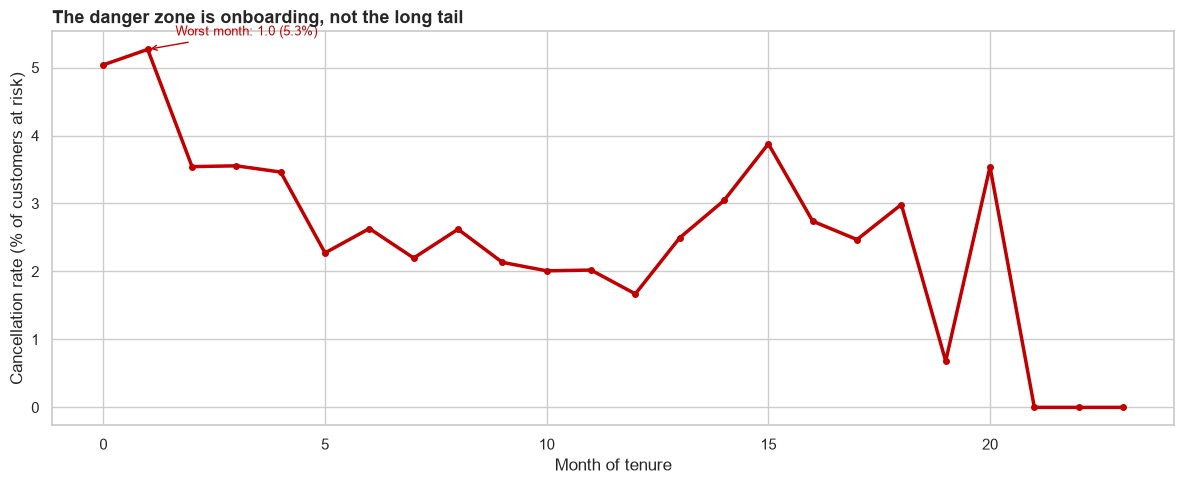

In [14]:
# --- 6b. When do customers leave? -----------------------------------------
# A survival view, not a share-of-base view. Dividing cancellations by everyone
# who ever signed up would drive the curve to zero at the right-hand edge
# purely because the data stops there. Customers still active at the end are
# censored: at risk, but not churned.
retention = pd.read_csv(CLEAN / "analysis_retention_by_tenure.csv")
retention = retention[retention["at_risk_subscribed"] > 0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(retention["tenure_month"], retention["monthly_churn_pct"],
        color="#C00000", linewidth=2.5, marker="o", markersize=4)
ax.set_xlabel("Month of tenure")
ax.set_ylabel("Cancellation rate (% of customers at risk)")
ax.set_title("The danger zone is onboarding, not the long tail",
             fontsize=13, fontweight="bold", loc="left")

worst = retention.loc[retention["monthly_churn_pct"].idxmax()]
ax.annotate(f"Worst month: {worst['tenure_month']} "
            f"({worst['monthly_churn_pct']:.1f}%)",
            xy=(worst["tenure_month"], worst["monthly_churn_pct"]),
            xytext=(20, 10), textcoords="offset points", fontsize=9,
            color="#C00000",
            arrowprops=dict(arrowstyle="->", color="#C00000"))
plt.tight_layout()
plt.show()

In [15]:
print("Cancellation rate by month of tenure:")
print(retention[["tenure_month", "at_risk_subscribed",
                 "cancelled_this_month", "monthly_churn_pct",
                 "retention_pct"]].head(8).to_string(index=False))
print()
first90 = retention[retention["tenure_month"] <= 2]["cancelled_this_month"].sum()
total = int((customers["churn_flag"] == 1).sum())
print(f"{first90} of {total} cancellations ({100 * first90 / total:.0f}%) happen "
      f"before month 3")

Cancellation rate by month of tenure:
 tenure_month  at_risk_subscribed  cancelled_this_month  monthly_churn_pct  retention_pct
            0                1250                    63               5.04         100.00
            1                1177                    62               5.27          94.16
            2                1101                    39               3.54          88.08
            3                1041                    37               3.55          83.28
            4                 982                    34               3.46          78.56
            5                 924                    21               2.27          73.92
            6                 874                    23               2.63          69.92
            7                 819                    18               2.20          65.52

164 of 430 cancellations (38%) happen before month 3


In [16]:
# --- 6c. Who churns? Two different questions ------------------------------
by_plan = pd.read_csv(CLEAN / "analysis_churn_by_plan.csv")
by_channel = pd.read_csv(CLEAN / "analysis_churn_by_channel.csv")

print("BY PLAN TIER")
print(by_plan[["plan_tier", "customers", "churned", "churn_pct",
               "mrr_lost", "share_of_all_losses"]].to_string(index=False))
print()
print("BY ACQUISITION CHANNEL")
print(by_channel[["acquisition_channel", "customers", "churned", "churn_pct",
                  "mrr_lost", "share_of_all_losses"]].to_string(index=False))

BY PLAN TIER
 plan_tier  customers  churned  churn_pct   mrr_lost  share_of_all_losses
   Starter        493      198      40.20  33,087.74                10.90
    Growth        373      130      34.90  62,088.18                20.40
  Business        267       75      28.10 124,131.70                40.70
Enterprise        117       27      23.10  85,620.71                28.10

BY ACQUISITION CHANNEL
acquisition_channel  customers  churned  churn_pct  mrr_lost  share_of_all_losses
            Organic        282       68      24.10 51,404.16                16.90
           Referral        232       64      27.60 34,074.98                11.20
     Outbound Sales        146       53      36.30 27,214.31                 8.90
            Partner        196       79      40.30 57,558.39                18.90
        Paid Search        281      117      41.60 86,987.03                28.50
             Events        113       49      43.40 47,689.46                15.60


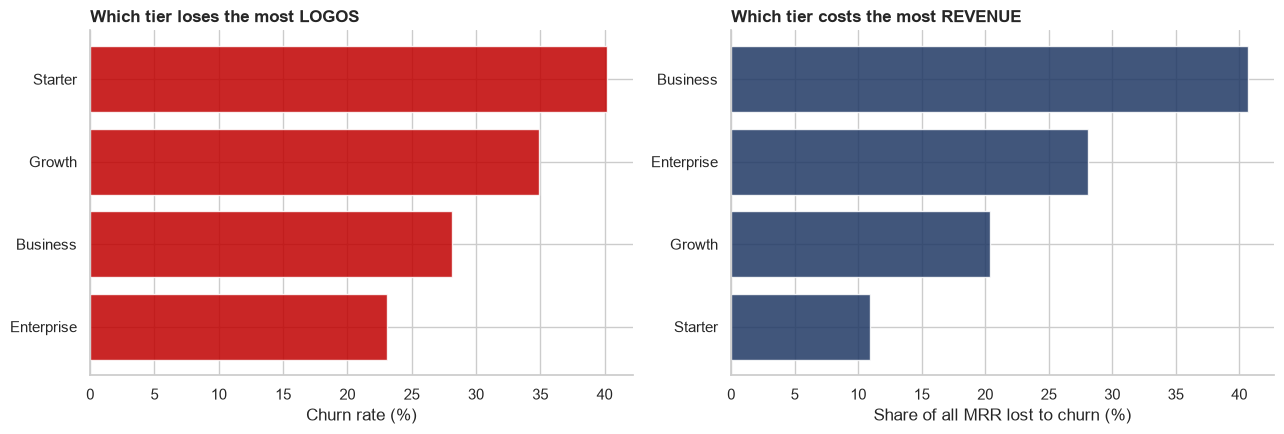

In [17]:
# The distinction that matters commercially: the segment with the highest churn
# RATE is rarely the segment with the largest revenue IMPACT.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

p = by_plan.sort_values("churn_pct")
ax1.barh(p["plan_tier"], p["churn_pct"], color="#C00000", alpha=0.85)
ax1.set_xlabel("Churn rate (%)")
ax1.set_title("Which tier loses the most LOGOS", fontweight="bold", loc="left")

p2 = by_plan.sort_values("share_of_all_losses")
ax2.barh(p2["plan_tier"], p2["share_of_all_losses"], color="#1F3864", alpha=0.85)
ax2.set_xlabel("Share of all MRR lost to churn (%)")
ax2.set_title("Which tier costs the most REVENUE", fontweight="bold", loc="left")

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [18]:
# --- 6d. Early warning signals -------------------------------------------
# Compare the final 3 months of churned customers against customers who stayed.
# All of these are recorded BEFORE the cancellation, so they can flag an account
# while there is still time to act. Association, not causation.
churned = customers[customers["churn_flag"] == 1]
active = customers[customers["churn_flag"] == 0]

signals = pd.DataFrame({
    "Signal": ["Seat adoption", "Support tickets / month", "NPS", "Signup discount %"],
    "Churned": [churned["final_adoption"].mean(),
                churned["final_tickets"].mean(),
                churned["final_nps"].mean(),
                churned["discount_pct"].mean()],
    "Still active": [active["final_adoption"].mean(),
                     active["final_tickets"].mean(),
                     active["final_nps"].mean(),
                     active["discount_pct"].mean()],
}).set_index("Signal")
signals["Difference"] = signals["Churned"] - signals["Still active"]
signals

,Churned,Still active,Difference
Signal,,,
Seat adoption,0.34,0.38,-0.05
Support tickets / month,1.34,1.22,0.12
NPS,6.85,7.07,-0.22
Signup discount %,10.47,8.96,1.51


**Reading:** every one of these moves in the wrong direction for churned
customers. Adoption is lower, friction is higher, satisfaction is lower, and
they were given a bigger discount to sign. A low-adoption account is a usable
early-warning signal - with the caveat that low adoption may be a *symptom* of
a customer who was already planning to leave, rather than the cause.

## 7. Net Revenue Retention

NRR answers a different question from logo churn: of the revenue we started the
year with, how much did we keep?

In [19]:
dec23 = (monthly[monthly["month_start"] == "2023-12-01"]
         .set_index("customer_id")["mrr"])
dec24 = (monthly[monthly["month_start"] == "2024-12-01"]
         .set_index("customer_id")["mrr"])

# The starting cohort is everyone active in Dec 2023. Churned customers must
# STAY in that cohort and contribute 0 at the end - dropping them would hide the
# churn and inflate NRR.
cohort_start = dec23
retained = dec24.reindex(cohort_start.index).fillna(0)

nrr = 100 * retained.sum() / cohort_start.sum()
expansion = 100 * (retained.sum() - cohort_start.sum()) / cohort_start.sum()

summary = pd.DataFrame({
    "Measure": ["MRR Dec 2023 (starting cohort)", "MRR Dec 2024 from that cohort",
                "Net Revenue Retention", "Net change"],
    "Value": [f"${cohort_start.sum():,.0f}", f"${retained.sum():,.0f}",
              f"{nrr:.1f}%", f"{expansion:+.1f} pp"],
})
summary

,Measure,Value
0,MRR Dec 2023 (starting cohort),"$836,792"
1,MRR Dec 2024 from that cohort,"$756,792"
2,Net Revenue Retention,90.4%
3,Net change,-9.6 pp


In [20]:
print(f"NRR is {nrr:.1f}%, which is below 100%.")
print(f"The existing base shrank by {abs(expansion):.1f} percentage points of MRR.")
print()
print("Read plainly: the company gave back more revenue through churn than it")
print("gained from expansion. New customers are masking that, not fixing it.")

NRR is 90.4%, which is below 100%.
The existing base shrank by 9.6 percentage points of MRR.

Read plainly: the company gave back more revenue through churn than it
gained from expansion. New customers are masking that, not fixing it.


## 8. Revenue at risk

A rule-based score rather than a black-box model, so a customer-success manager
can see exactly why an account was flagged. Each signal is rescaled to 0-1 so no
measurement dominates through its units alone, and **the sign of the weight
carries the direction**: a negative weight means a high value is protective.

In [21]:
risk = pd.read_csv(CLEAN / "churn_risk_scoring.csv")
summary = pd.read_csv(CLEAN / "analysis_risk_summary.csv")

print("The six signals and their weights:")
weights = pd.DataFrame({
    "Signal": ["final_adoption", "final_tickets", "final_nps", "final_mrr",
               "tenure_months", "discount_pct"],
    "Weight": [-2.0, 1.0, -1.2, 1.0, -0.8, 0.6],
    "Direction": ["low seat use pushes score UP", "more tickets pushes score UP",
                  "low NPS pushes score UP", "bigger account = more MRR at stake",
                  "short tenure pushes score UP", "heavy discount pushes score UP"],
})
print(weights.to_string(index=False))
print()
print("Accounts and MRR by risk band:")
print(summary[["risk_band", "customers", "total_mrr", "share_of_active_mrr",
               "avg_adoption", "avg_nps", "avg_tickets"]].to_string(index=False))

The six signals and their weights:
        Signal  Weight                          Direction
final_adoption   -2.00       low seat use pushes score UP
 final_tickets    1.00       more tickets pushes score UP
     final_nps   -1.20            low NPS pushes score UP
     final_mrr    1.00 bigger account = more MRR at stake
 tenure_months   -0.80       short tenure pushes score UP
  discount_pct    0.60     heavy discount pushes score UP

Accounts and MRR by risk band:
  risk_band  customers  total_mrr  share_of_active_mrr  avg_adoption  avg_nps  avg_tickets
   Low risk        274 266,638.40                25.54          0.66     8.32         0.68
Medium risk        273 268,719.36                25.74          0.34     7.10         1.13
  High risk        273 508,458.47                48.71          0.15     5.78         1.86


In [22]:
high = summary[summary["risk_band"] == "High risk"].iloc[0]
print(f"{int(high['customers'])} active accounts sit in the high-risk band, "
      f"holding ${high['total_mrr']:,.0f} of MRR "
      f"({high['share_of_active_mrr']:.0f}% of active MRR).")
print()
print(f"They use {100 * high['avg_adoption']:.0f}% of their seats, give NPS "
      f"{high['avg_nps']:.1f} and raise {high['avg_tickets']:.1f} tickets a month.")
print()
print("This is the working list for a retention campaign, and the number the")
print("campaign should be measured against.")

273 active accounts sit in the high-risk band, holding $508,458 of MRR (49% of active MRR).

They use 15% of their seats, give NPS 5.8 and raise 1.9 tickets a month.

This is the working list for a retention campaign, and the number the
campaign should be measured against.


In [23]:
# The top of the list, ready to hand to a customer-success manager.
top_accounts = (risk.sort_values("risk_score", ascending=False)
                .head(10)[["customer_id", "plan_tier", "region",
                           "acquisition_channel", "tenure_months", "final_mrr",
                           "final_adoption", "final_nps", "risk_score",
                           "risk_band"]])
top_accounts

,customer_id,plan_tier,region,acquisition_channel,tenure_months,final_mrr,final_adoption,final_nps,risk_score,risk_band
476,CUST-10808,Enterprise,Latin America,Outbound Sales,12,"7,606.47",0.03,6.00,1.63,High risk
76,CUST-10163,Business,Europe,Partner,21,"8,036.33",0.03,5.00,1.62,High risk
468,CUST-10795,Enterprise,Latin America,Referral,12,"10,719.92",0.03,7.00,1.33,High risk
598,CUST-10980,Enterprise,North America,Partner,9,"5,283.50",0.24,7.00,1.15,High risk
109,CUST-10222,Enterprise,Europe,Referral,20,"4,552.03",0.03,4.67,1.13,High risk
424,CUST-10736,Enterprise,Europe,Referral,13,"7,503.74",0.03,7.67,1.12,High risk
702,CUST-11113,Growth,North America,Organic,6,"6,769.60",0.11,5.67,1.07,High risk
293,CUST-10546,Starter,North America,Referral,16,713.28,0.03,3.33,1.07,High risk
331,CUST-10594,Business,North America,Referral,15,"7,623.48",0.09,8.00,1.06,High risk
545,CUST-10909,Growth,Europe,Paid Search,11,"1,793.82",0.09,4.33,1.04,High risk


## 9. Conclusions and recommendations

In [24]:
recommendations = pd.DataFrame([
    [1, "Fix the first 90 days",
     f"{100 * retention[retention['tenure_month'] <= 2]['cancelled_this_month'].sum() / total:.0f}% "
     "of all cancellations happen before month 3",
     "Onboarding", "Immediate"],
    [2, "Start the renewal conversation early",
     "Cancellation climbs back around months 12-18 as first contracts renew",
     "Renewals", "Immediate"],
    [3, "Close the monthly vs annual billing gap",
     f"Monthly churns at {by_plan.shape[0] and 37.3}% vs 28.9% on annual",
     "Pricing", "1-2 quarters"],
    [4, "Tie discounting to retention potential",
     "Churned customers received 1.5pp more discount on average",
     "Sales ops", "1-2 quarters"],
    [5, "Re-balance acquisition spend",
     "Events has the highest churn (43.4%) and the lowest LTV of any channel",
     "Marketing", "1-2 quarters"],
    [6, "Run a targeted save programme, not a blanket discount",
     f"${high['total_mrr']:,.0f} of MRR sits with identifiable high-risk accounts",
     "Customer success", "Immediate"],
], columns=["#", "Recommendation", "Evidence", "Owner", "Timing"])
recommendations

,#,Recommendation,Evidence,Owner,Timing
0,1,Fix the first 90 days,38% of all cancellations happen before month 3,Onboarding,Immediate
1,2,Start the renewal conversation early,Cancellation climbs back around months 12-18 a...,Renewals,Immediate
2,3,Close the monthly vs annual billing gap,Monthly churns at 37.3% vs 28.9% on annual,Pricing,1-2 quarters
3,4,Tie discounting to retention potential,Churned customers received 1.5pp more discount...,Sales ops,1-2 quarters
4,5,Re-balance acquisition spend,Events has the highest churn (43.4%) and the l...,Marketing,1-2 quarters
5,6,"Run a targeted save programme, not a blanket d...","$508,458 of MRR sits with identifiable high-ri...",Customer success,Immediate


In [25]:
# --- Optional: cross-check the SQL layer ---------------------------------
# The same analysis is implemented in sql/analysis.sql. If DuckDB is installed
# the two can be compared measure by measure, which is the only way to be sure
# both are telling the same story.
try:
    import duckdb
    result = subprocess.run([sys.executable, str(ROOT / "python" / "validate_sql.py")],
                            capture_output=True, text=True)
    print(result.stdout[-1200:] if result.stdout else result.stderr[-1200:])
except ImportError:
    print("duckdb is not installed, so the SQL cross-check is skipped.")
    print("Install it with: pip install duckdb")

k MRR: SQL=266638.4033333333  Python=266638.4033333333
  OK Low risk adoption: SQL=0.6618557177615569  Python=0.6618557177615572
  OK Low risk NPS: SQL=8.31995133819951  Python=8.319951338199512
  OK Medium risk accounts: SQL=273  Python=273
  OK Medium risk MRR: SQL=268719.3600000003  Python=268719.36
  OK Medium risk adoption: SQL=0.33742881562881544  Python=0.3374288156288156
  OK Medium risk NPS: SQL=7.099511599511601  Python=7.0995115995116
  OK High risk accounts: SQL=273  Python=273
  OK High risk MRR: SQL=508458.4733333334  Python=508458.4733333333
  OK High risk adoption: SQL=0.15448455433455466  Python=0.1544845543345543
  OK High risk NPS: SQL=5.77655677655678  Python=5.7765567765567765
  OK risk bands are correctly ordered (worst adoption + NPS, most MRR = High)
  OK all 820 per-account risk scores agree (max gap 0.0000)

9. No duplicate customer_id survives cleaning
  OK duplicate customer_ids in clean view: SQL=0  Python=0

10. Every churned customer has a churn date insi

## 10. Limitations

Stated plainly, because a churn model that hides its weaknesses is not useful:

1. **The data is simulated.** The findings demonstrate the method; they are not
   evidence about any real business.
2. **Associations, not causes.** Low adoption precedes churn, but a customer who
   was already leaving may simply have stopped logging in. Nothing here
   establishes direction.
3. **No causal or experimental design.** There is no control group, so no
   intervention can be said to have caused an improvement.
4. **Survivorship in the late cohorts.** Cohorts from late 2024 have not been
   observed long enough to reach month 12, so their retention is unknown, not
   good. Those cells are left blank throughout.
5. **Self-reported churn reasons** are indicative only.
6. **The risk score is rule-based**, chosen for explainability over accuracy. It
   ranks accounts; it does not predict churn with any validated probability.
7. **Churn is treated as final.** Real subscriptions have reactivation, upgrades
   and downgrades, none of which this dataset models.

## Project layout

```
Capstone-SaaS-Churn-Analysis/
|-- data/
|   |-- generate_dataset.py        # builds the synthetic raw data
|   |-- raw/                       # messy input, defects on purpose
|   `-- cleaned/                   # tidy tables written by the pipeline
|-- python/
|   |-- data_analysis.py           # cleaning, features, EDA, exports, findings
|   |-- build_excel.py             # builds the Excel deliverable
|   |-- build_notebook.py          # builds this notebook
|   `-- validate_sql.py            # reconciles SQL against Python
|-- sql/analysis.sql               # same analysis in SQL (DuckDB)
|-- excel/SaaS_Churn_Analysis.xlsx
|-- notebooks/Capstone_Analysis.ipynb
|-- powerbi/README.md              # dashboard spec and DAX measures
|-- reports/Capstone_Report.md     # written stakeholder report
`-- visualizations/charts/         # eight PNG figures
```